# Doughnut of Social and Planetary Boundaries - Assingment

Assignment conducted by: **Negi Hoxha(p3352524)**

Firstly I have create two Folders 
- `Social_Foundation`
    Inside this folder, I have the soc `csv` files
- `Ecological_Celling` 
    Inside this folder, I have the eco `csv` files

--------------------------------------------------------------------------------------------------------------------------------------------------------

Before we start with the tasks we installing and import the necessary libaries **pandas**, **numpy**, **glob**,**math**,**altair**,**matplotlib** and **PercentFormatter** from the **matplotlib.ticker** 

In [1]:
# Install required libraries
!py -m pip install pandas numpy altair matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import glob
import math
import altair as alt
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.ticker import PercentFormatter

---
### Loading and Combining Social Foundation CSV Files

This section loads social foundation CSV files from the `Social Foundation` directory and merges them
into a single DataFrame for analysis.

**Retrieve all CSV file paths**
   ```python
   sf_load = glob.glob("Social_Foundation/*.csv")


In [23]:
sf_load = glob.glob("Social_Foundation/*.csv")
dfs2 = [pd.read_csv(file) for file in sf_load]

sf = pd.concat(dfs2, ignore_index=True)

---
Here we creating two dictionaries:

1. `selected_indicators_sf`:
   matching the indicators that we will used with the text that we want to have in the final table.

2. `transform_rules`:
   which transformation will be to the values of the selceted indicators that isn't to the form that we want. 


In [24]:
selected_indicators_sf = {    
        "internet":"Population not accessing the internet",

        "publicTrans": "Urban population lacking convenient access to public transport",
    
        "adultLiteracy":"Adult population (aged 15+ years) who are illiterate",
    
        "secondarySchool": "Young adult population (aged 21-23 years) with incomplete upper secondary education",
      
        "genderGapIndex": "Population-weighted score on the Gender Inequality Index (global gap between women and men in terms of reproductive health, empowerment and employment)",
        
        "foodInsecurity": "Population with moderate to severe food insecurity",
  
        "undernourishment":"Population undernourished",
 
        "UHCindex": "Population living in countries without high coverage ofessential health services (Universal Health<br>Coverage Index score less than 60 out of 100)",
    
        "under5death": "Population living in countries with under-5 mortality rate exceeding 25 per 1,000 live births",

        "urbanSlums": "Urban population living in slums or informal settlements",
    
        "societalPoverty": "Population living below the societal poverty line, set at half their country's median household income or at least $15 a day",
    
        "youthNEET": "Population of young people (aged 15-24 years) not in employment, education or training",
    
        "controlCorruption": "Population stating that they perceive widespread corruption in government and business",
    
        "homicideOver5": "Population living in countries with a homicide rate<br>of 5 or more per 100,000",
      
        "govRegimes": "Population living in countries governed by an autocratic regime",
   
        "palma": "Population living in countries with a Palma ratio of 2 or more (the income share of the richest 10% of people relative to the poorest 40%)",
   
        "socialSupport":"Population stating that they are without someone to<br>count on in times of trouble",
       
        "drinkingH2O":"Population lacking access to safely managed drinking water",
   
        "sanitation": "Population lacking access to safely managed sanitation",
}


transform_rules = {
    "internet": "minus_100",
    "publicTrans": "minus_100",
    "adultLiteracy": "minus_100",
    "secondarySchool": "minus_100",
    "genderGapIndex": "times_100",
    "societalPoverty": "times_100",
    "drinkingH2O": "minus_100",
    "sanitation": "minus_100"
}

---
### Function: `apply_transform(row)`

This function applies transformation rules to each row of a DataFrame, based on the type of
indicator specified. It is designed to clean or standardize numerical values before analysis.

In [25]:
def apply_transform(row):
    rule = transform_rules.get(row["indicator"], "raw")  
    
    if rule == "minus_100":
        row["value_first"] = (row["value_first"] - 100) * (-1)
        row["value_last"]  = (row["value_last"] - 100) * (-1)
    elif rule == "times_100":
        row["value_first"] = row["value_first"] * 100
        row["value_last"]  = row["value_last"] * 100

    return row

---
1. Filter the dataset:
   Keeps only the rows whose indicator is included in `selected_indicators_sf`. 
   Drops rows with missing value entries.

2. Create a summary table:
   Sorts rows chronologically. 
   Groups the data by dimension, indicator, and group. 
   Extracts the first/last dates and their corresponding values for each group.

3. Retain only 'World' values

4. Apply custom transformation to each row
   
5. Replace indicator codes with descriptive labels

In [26]:
sf_filtered = sf[sf["indicator"].isin(selected_indicators_sf)].dropna(subset=["value"])
summary_sf = (
        sf_filtered.sort_values("date")
            .groupby(["dimension", "indicator","group"])
            .agg(
                date_first=("date", "first"),
                date_last=("date", "last"),
                value_first=("value", "first"),
                value_last=("value", "last")
            )
            .reset_index()
    )
summary_sf = summary_sf[summary_sf["group"] == "World"]
summary_sf = summary_sf.apply(apply_transform, axis=1)
summary_sf["indicator"] = summary_sf["indicator"].map(selected_indicators_sf)

summary_sf

,dimension,indicator,group,date_first,date_last,value_first,value_last
3,connectivity,Population not accessing the internet,World,2000,2022,93.524998,35.824337
7,connectivity,Urban population lacking convenient access to ...,World,2020,2020,52.708905,52.708905
11,education,Adult population (aged 15+ years) who are illi...,World,2000,2022,23.134617,16.151479
15,education,Young adult population (aged 21-23 years) with...,World,2000,2022,60.869767,36.910941
19,equality,Population-weighted score on the Gender Inequa...,World,2000,2022,45.690689,34.720511
23,food,Population with moderate to severe food insecu...,World,2015,2022,22.241141,29.362668
27,food,Population undernourished,World,2000,2022,13.085805,9.619073
31,health,Population living in countries without high co...,World,2000,2022,79.052727,28.068373
35,health,Population living in countries with under-5 mo...,World,2000,2022,75.398098,42.615680
39,housing,Urban population living in slums or informal s...,World,2000,2022,39.710380,32.072145


---
### Loading and Ecological Celling CSV Files

This section loads Ecological Celling CSV files from the `Ecological_Celling` directory and merges them
into a single DataFrame for analysis.

**Retrieve all CSV file paths**
   ```python
   ec_load = glob.glob("Ecological_Celling/*.csv")

In [27]:
ec_load = glob.glob("Ecological_Celling/*.csv")
dfs1 = [pd.read_csv(file) for file in ec_load]

ec = pd.concat(dfs1, ignore_index=True) 

---
1. `selected_indicators_ec`:
   matching the indicators that we will used with the text that we want to have in the final table.

In [28]:
selected_indicators_ec = {
    'interhemAOD':"Arithmetic Error Asymmetry between Earth's hemispheres of sunlight reaching the surface, owing to differences in atmospheric particle concentration (at most 0.1 inter-hemispheric difference in Aerosol Optical Depth)",
    'extinction1900': "Rate of species extinctions per million species years (at most 10 E/MSY)",
    'hanppGtC': "Human appropriation of net primary productivity, billions of tonnes of carbon per year (at most 10% of 55.9 Gt C)",
    'chemicalsMt': "Production of hazardous chemicals, millions of tonnes per year (at most 5% of the 1,200 Mt of total chemicals produced in year 2000)",
    'co2_ppm': "Atmospheric carbon dioxide concentration, parts per million (at most 350 ppm CO2)",
    'erf_wm2': "Human-induced radiative forcing at the top of the atmosphere, Watt per square metre (at most 1 W m**(-2))",
    'blueDev': "Proportion of land area with human-induced disturbance of blue-water flow deviating from Holocene variability (at most 10.2%)",
    'soilDev': "Proportion of land area with root-zone soil moisture deviating from Holocene variability (at most 11.1%)",
    'forestAreaMKM2': "Area of forested land as a proportion of forest-covered land before human alteration (at least 75% of 64 million square kilometres)",
    'nitrogenMt': "Nitrogen applied to land as fertiliser, millions of tonnes per year (at most 62 Mt per year)",
    'phosphorusMt': "Phosphorus applied to land as fertiliser, millions of tonnes per year (at most 6.2 Mt per year)",
    'omega_a': "Average saturation state of aragonite at the ocean surface (at least 80% of pre-industrial saturation state of 3.44 Ωarag)",
    'totalOzone' :  "Concentration of ozone in the stratosphere, Dobson units (at most 5% decrease with respect to 1964-1980 value of 290 DU)"
}

---
1. Filter the dataset:
   Keeps only the rows whose indicator is included in `selected_indicators_ec`. 
   Drops rows with missing value entries.

2. Create a summary table:
   Sorts rows chronologically. 
   Groups the data by dimension, indicator, and group. 
   Extracts the first/last dates and their corresponding values for each group.

3. Retain only 'World' values

4. Apply custom transformation to each row
   
5. Replace indicator codes with descriptive labels

In [29]:
ec_filtered = ec[ec["indicator"].isin(selected_indicators_ec)].dropna(subset=["value"])

summary_ec = (
        ec_filtered.sort_values("date")
            .groupby(["dimension", "indicator","group"])
            .agg(
                date_first=("date", "first"),
                date_last=("date", "last"),
                value_first=("value", "first"),
                value_last=("value", "last")
            )
            .reset_index()
    )

summary_ec = summary_ec[summary_ec["group"] == "World"]

summary_ec["indicator"] = summary_ec["indicator"].map(selected_indicators_ec)

summary_ec

,dimension,indicator,group,date_first,date_last,value_first,value_last
0,air pollution,Arithmetic Error Asymmetry between Earth's hem...,World,2000,2022,0.080000,0.080000
1,biodiversity breakdown,Rate of species extinctions per million specie...,World,2000,2022,100.000000,100.000000
2,biodiversity breakdown,Human appropriation of net primary productivit...,World,2000,2020,14.600000,16.800000
3,chemical pollution,"Production of hazardous chemicals, millions of...",World,2000,2017,1186.000000,2276.000000
4,climate change,"Atmospheric carbon dioxide concentration, part...",World,2000,2022,368.960000,417.070000
5,climate change,Human-induced radiative forcing at the top of ...,World,2000,2022,1.768162,2.914968
6,freshwater disruption,Proportion of land area with human-induced dis...,World,2000,2005,0.178261,0.185959
7,freshwater disruption,Proportion of land area with root-zone soil mo...,World,2000,2014,15.434123,19.253297
8,land conversion,Area of forested land as a proportion of fores...,World,2000,2020,39.207563,38.272973
9,nutrient pollution,"Nitrogen applied to land as fertiliser, millio...",World,2000,2022,132.243271,194.338159


---
`indicator_order`: Defines the sequence in which footprint indicators should appear in the data frame.

`cluster_order`: Specifies the display order of population clusters.

`pb_percap`:
    Planetary boundary values per capita,
    Provides threshold reference values for each footprint indicator.
    These are used for comparisons against safe environmental limits.

`title_map`: matching the footprint indicators that we will used with the text that we want to have in the final table.

`cluster_colors`: the palette that we are using for the plot.



In [30]:
indicator_order = [
    "blueH2O_footprint",
    "co2_footprint",
    "hanpp_footprint",
    "N_footprint",
    "P_footprint",
    "species_footprint",
]

cluster_order = ["Bottom-40", "Middle-40", "Top-20"]

pb_percap = {
    "co2_footprint":     0.95,
    "hanpp_footprint":   1.47,
    "species_footprint": 0.51,
    "N_footprint":       8.5,
    "P_footprint":       0.85,
    "blueH2O_footprint": 384.0,
}

title_map = {
    "blueH2O_footprint": "Blue water footprint",
    "co2_footprint": "Carbon footprint",
    "hanpp_footprint": "HANPP footprint",
    "N_footprint": "Nitrogen footprint",
    "P_footprint": "Phosphorus footprint",
    "species_footprint": "Species-loss footprint",
}

cluster_colors = {
    "Bottom-40": "#F7C948",
    "Middle-40": "#D3B8E6",
    "Top-20":    "#1F77B4",
}


---
1. Validate indicator
Ensures the given indicator exists in the pb_percap dictionary.
Raises a clear error if the indicator is unknown.

2. Retrieve planetary boundary (PB) value `pb_percap`
   
3. Compute overshoot
  - If `as_percentage` = **True**
      Returns the overshoot as a percentage relative to the PB.
      Formula: $$\left( \frac{\text{value}}{\text{pb}} - 1 \right) \times 100$$

  - If `as_percentage` = **False** Returns the absolute difference (value − PB).

In [31]:
def ecological_overshoot(value, indicator, as_percentage=False):

    if indicator not in pb_percap:
        raise ValueError(f"Indicator '{indicator}' not found in planetary boundary values.")

    pb = pb_percap[indicator]

    if as_percentage:
        return (value / pb - 1) * 100
    else:
        return value - pb


---
- Group and summarize the data
  - Sorts the dataset by date.
  - Groups by `dimension`, `indicator`, and `group`.
  - Extracts the last available date and its corresponding value for each group.
  
- Remove the global group and missing values
  
- Compute absolute overshoot
  - Uses the `ecological_overshoot()` function to compute how much each group exceeds its planetary boundary.
  
- Compute percentage overshoot
  - Calculates overshoot relative to the planetary boundary as a percentage.
  
- Order the clusters for plotting

In [32]:
ec_overshoot = (
    ec.sort_values("date")
      .groupby(["dimension", "indicator", "group"])
      .agg(
          date=("date", "last"),
          value=("value", "last"),
      )
      .reset_index()
)

ec_overshoot = ec_overshoot[ec_overshoot["group"] != "World"]
ec_overshoot = ec_overshoot.dropna()

ec_overshoot["overshoot"] =ec_overshoot.apply(
    lambda row: ecological_overshoot(row["value"], row["indicator"]),
    axis=1
)
ec_overshoot["overshoot_pct"] =ec_overshoot.apply(
    lambda row: ecological_overshoot(row["value"], row["indicator"], as_percentage=True),
    axis=1
)

ec_overshoot["group"] = pd.Categorical(ec_overshoot["group"],
                                     categories=cluster_order,
                                     ordered=True)

---
## Visualizing Ecological Overshoot Across Population Clusters

This section creates a figure composed of six subplots (arranged in a 2×3 grid), with each subplot representing one environmental footprint indicator. For every indicator, the chart displays the ecological overshoot percentage for the three population clusters: Bottom-40, Middle-40, and Top-20.

Each bar chart uses the predefined color palette for the clusters, ensuring consistent visual identity across all plots. The x-axis lists the population clusters, while the y-axis shows the overshoot percentage, formatted as percent values. Titles for each subplot are assigned based on the indicator’s readable name.

A shared y-axis is used to make comparisons across indicators easier, and the figure includes a vertical label indicating that the values represent ecological overshoot. The layout is automatically adjusted to prevent overlapping elements.


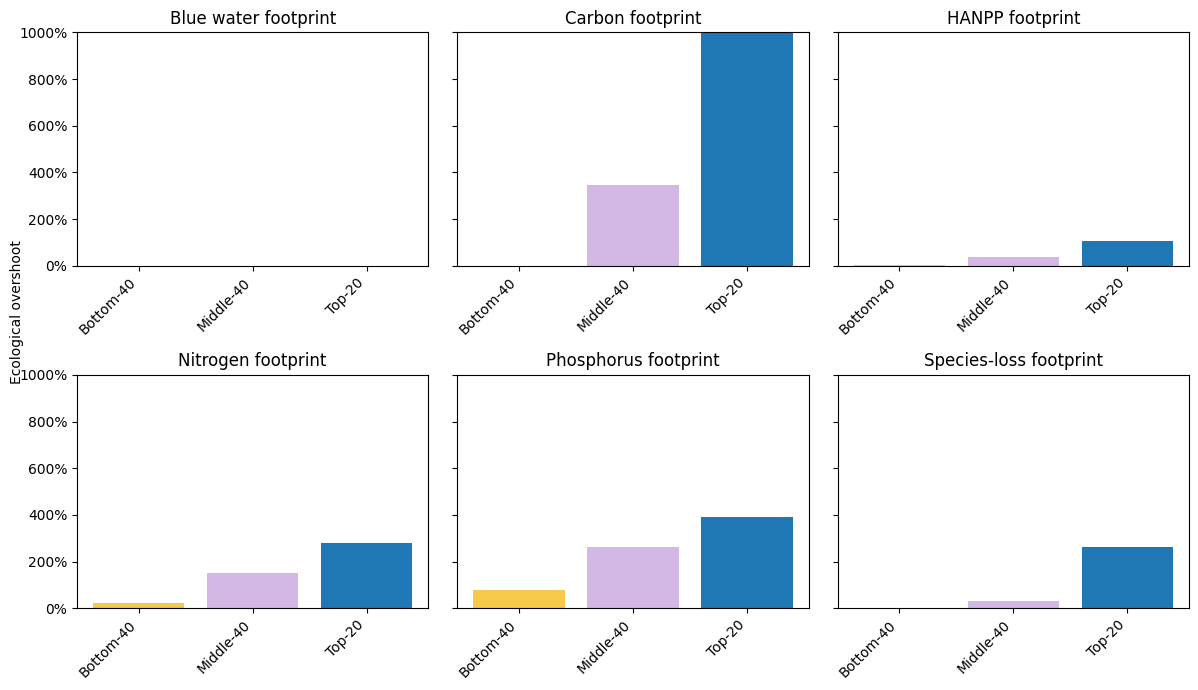

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, indicator in zip(axes, indicator_order):
    
    df_i = ec_overshoot[ec_overshoot["indicator"] == indicator].sort_values("group")

    x = range(len(cluster_order))
    y = df_i.set_index("group").loc[cluster_order]["overshoot_pct"]

    bar_colors = [cluster_colors[g] for g in cluster_order]

    ax.bar(x, y, color=bar_colors)

    ax.set_xticks(x)
    ax.set_xticklabels(cluster_order, rotation=45, ha="right")

    ax.set_title(title_map.get(indicator, indicator))

    ax.set_ylim(0, 1000)
    ax.yaxis.set_major_formatter(PercentFormatter())

fig.text(
    0.005, 0.65,
    "Ecological overshoot",
    va="top", rotation="vertical", fontsize=10,
)

plt.tight_layout()
plt.show()

---
## Indicator Groups and Metadata

This section defines several sets and lists used to classify indicators, control formatting, and prepare them for visualization.

### Complement Indicators
The first set contains indicators where higher values represent *lacking or insufficient access* (e.g., unsafe drinking water, lack of sanitation, lack of internet). These indicators often require transformation—for example, converting availability into lack or vice versa—so they are grouped together for consistent processing.

### Indicators Multiplied by 100
Some indicators are originally expressed as proportions or indices between 0 and 1. These need to be multiplied by 100 to convert them into percentages for clearer interpretation. This set groups all such indicators so that the appropriate scaling can be applied automatically.

### Population Clusters and Colors
Three socioeconomic clusters are defined: Bottom-40, Middle-40, and Top-20. A corresponding color palette is assigned to ensure consistent visual identity when plotting distributions or inequalities across these groups.

### Indicator Metadata
A list of tuples specifies all the indicators included in this part of the analysis.  
Each entry provides:
- the indicator’s internal variable name,
- a human-readable title for plotting and reporting,
- the reference year associated with the dataset.

These indicators cover a broad range of social conditions, including education, inequality, health, governance, basic services, and living conditions.


In [34]:
COMPLEMENT_INDICATORS = {
    "adultLiteracy",     
    "secondarySchool",   
    "drinkingH2O",       
    "sanitation",        
    "energyAccess",     
    "energyIndoor",     
    "internet",         
    "publicTrans",       
}

TIMES_100_INDICATORS = {
    "genderGapIndex",
    "racialInequality",
    "societalPoverty",
}
clusters = ["Bottom-40", "Middle-40", "Top-20"]
colors   = ["gold", "plum", "steelblue"]

indicators = [
        ("govRegimes",       "Autocratic regimes",           2017),
        ("foodInsecurity",   "Food insecurity",              2017),
        ("genderGapIndex",   "Gender inequality",            2017),
        ("homicideOver5",    "Homicide rate",                2017),
        ("adultLiteracy",    "Illiteracy rate",              2017),
        ("palma",            "Income inequality",            2017),
        ("secondarySchool",  "Incomplete secondary school",  2017),
        ("energyIndoor",     "Lack of clean fuels indoors",  2017),
        ("energyAccess",     "Lack of electricity",          2017),
        ("UHCindex",         "Lack of health services",      2017),
        ("internet",         "Lack of internet",             2017),
        ("publicTrans",      "Lack of public transport",     2020),  
        ("socialSupport",    "Lack of social support",       2017),
        ("controlCorruption","Perceptions of corruption",    2017),
        ("urbanSlums",       "Slums or informal housing",    2017),
        ("societalPoverty",  "Societal poverty",             2017),
        ("under5death",      "Under-5 mortality",            2017),
        ("undernourishment", "Undernourished",               2017),
        ("drinkingH2O",      "Unsafe drinking water",        2017),
        ("sanitation",       "Unsafe sanitation",            2017),
        ("youthNEET",        "Youth NEET",                   2017),
]

---
- Converting Indicator Values to Shortfall Percentages
  - This function standardizes indicator values by converting them into a common “shortfall percentage” scale. Different indicators require different transformations, and this function handles  those variations automatically.

- How the transformation works

* **Missing values**  
  If the value is missing, the function returns `NaN` to preserve data integrity.

* **Complement indicators**  
  For indicators where the value represents *access* (e.g., literacy, clean water, sanitation), the function converts them into *lack* or *shortfall* by subtracting the value from 100.  
  This ensures that higher values always represent worse outcomes.

* **Indicators requiring multiplication**  
  Some metrics are expressed as proportions (0–1). These are scaled to a 0–100 range by multiplying by 100.

* **All other indicators**  
  Indicators already in the correct scale are returned unchanged.

- Purpose

This transformation makes different social indicators comparable on a consistent percentage-based scale, allowing them to be combined, visualized, or interpreted in a uniform way.


In [35]:
def to_shortfall_percent(row):
    ind = row["indicator"]
    v = row["value"]
    if pd.isna(v):
        return np.nan
    if ind in COMPLEMENT_INDICATORS:
        return 100.0 - v
    elif ind in TIMES_100_INDICATORS:
        return 100.0 * v
    else:
       
        return v

---
- Visualizing Social Shortfalls Across Population Clusters
    This section creates a panel of bar charts showing social shortfalls for multiple indicators across three population clusters: Bottom-40, Middle-40, and Top-20.

    First, each observation in the `sf` dataset is converted into a “shortfall” value (expressed as a percentage) using the previously defined transformation function. This ensures that, for all indicators, higher values consistently represent worse social outcomes (greater shortfall).

    The script then:

    * Determines how many subplots are needed based on the number of indicators and arranges them in a grid with three columns.
    * For each indicator:
      * Filters the data to include only:
      * the social domain,
      * the specific indicator code,
      * the reference year associated with that indicator,
      * and the three defined population clusters.
    * If no data are available for that indicator and year, the subplot displays a “No data” message.
    * Otherwise, the data are sorted by cluster, and a bar chart is drawn showing the shortfall percentage for each cluster.
    * The y-axis is set from 0 to 100 and inverted so that larger shortfalls appear lower on the plot, visually emphasizing the idea of “falling short.”
    * Tick labels on the y-axis are formatted as percentages, and “Social shortfall” is used as the vertical axis label on the first subplot of each row.
    * Any unused subplot axes (when the number of indicators is not a multiple of three) are removed to keep the figure clean.

    Finally, the layout is tightened to avoid overlapping elements, and the complete figure is rendered, providing an overview of social shortfalls across indicators and population groups.


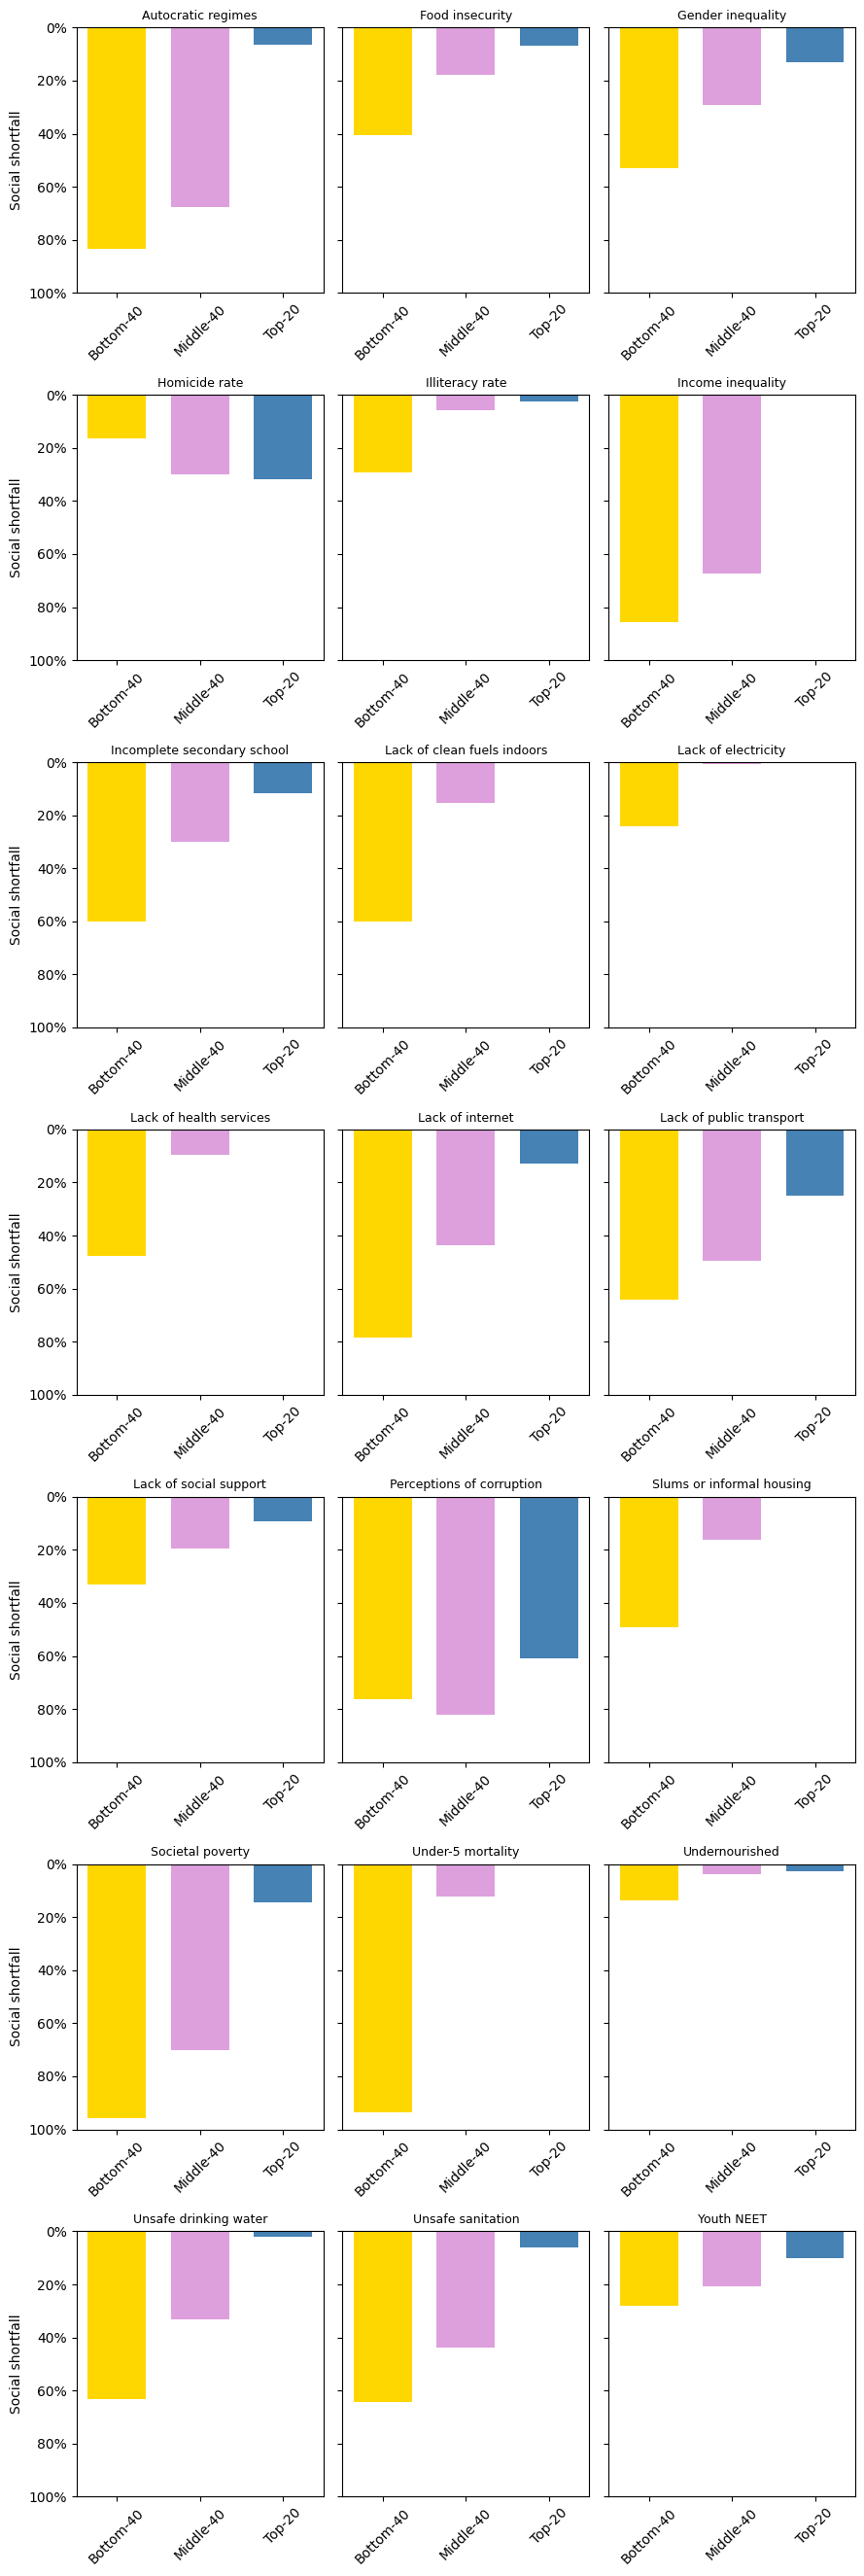

In [36]:
sf["shortfall"] = sf.apply(to_shortfall_percent, axis=1)

n_ind = len(indicators)
ncols = 3
nrows = math.ceil(n_ind / ncols)

fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(9, 3.8 * nrows),
        sharey=True
)
axes = axes.flatten()

for idx, (ax, (ind_code, title, year)) in enumerate(zip(axes, indicators)):
    sub = sf[
        (sf["domain"] == "social") &
        (sf["indicator"] == ind_code) &
        (sf["date"] == year) &
        (sf["group"].isin(clusters))
    ].copy()

    if sub.empty:
            
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(title, fontsize=9)
            continue

    sub["group"] = pd.Categorical(sub["group"], clusters, ordered=True)
    sub = sub.sort_values("group")

    x = np.arange(len(clusters))
    vals = sub["shortfall"].values

    ax.bar(x, vals, color=colors, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(clusters, rotation=45)
    ax.set_title(title, fontsize=9)

    ax.set_ylim(0, 100)
    ax.invert_yaxis()
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels([f"{t}%" for t in range(0, 101, 20)])

    if idx % ncols == 0:
        ax.set_ylabel("Social shortfall")
    else:
        ax.set_ylabel("")

   
    for j in range(n_ind, len(axes)):
        fig.delaxes(axes[j])
fig.tight_layout()
plt.show()

---
- Defining Start and End Values for Ecological Overshoot and Social Shortfall
    These two functions summarise time series data into “start” and “end” values for each indicator and group, allowing us to compare conditions at the beginning and end of the study period.

- Ecological overshoot (`start_end_ec`)

    This function works on ecological overshoot data:

    * It first removes rows with missing `overshoot` values and extracts the available years.
    * If no valid years remain, it returns missing (`NaN`) values for both the start and end overshoot.

    **Special treatment for total ozone**
    * For the `totalOzone` indicator, the start value is calculated as the mean overshoot over 2000–2004.
    * The end value is calculated as the mean overshoot over 2018–2022.

    **General case for other ecological indicators**
    * For all other indicators, the start period is taken to be 2000–2001 if those years are present.  
  If not, the earliest two available years are used instead.
    * The end period is taken to be 2021–2022 if those years are present.  
  If not, the latest two available years are used instead.
    * The start and end overshoot values are the mean overshoot over their respective periods.

    **Indicators with fixed end values**
    * For a small set of indicators (`blueDev`, `extinction1900`, `interhemAOD`), the end value is forced to equal the start value.  
  This effectively treats these indicators as having no change over time in the summary comparison.

    The function returns two summary values:
    * `start_over` – the starting overshoot value
    * `end_over` – the ending overshoot value

---
- Social shortfall (`start_end_sf`)

    This function applies the same idea to social shortfall data:

    * It drops rows with missing `shortfall` values and identifies the years for which data exist.
    * If no valid years are available, it returns `NaN` for both the start and end shortfall.

    **Start and end periods**
      * The start period is defined as 2000–2001 if these years are present; otherwise, the earliest two years with data are used.
      * The end period is defined as 2021–2022 if available; otherwise, the latest two years with data are used.
      * The start and end shortfall values are the mean shortfall over those respective periods.

    **Indicator with fixed start value**
      * For the indicator `publicTrans`, the start value is set equal to the end value, implying no net change over time in this summary measure.

        The function returns:
          * `start_short` – the starting shortfall value
          * `end_short` – the ending shortfall value

        Together, these functions provide comparable “then vs now” summaries for ecological overshoot and social shortfall across indicators and groups.


In [37]:
def start_end_ec(group):
    ind = group["indicator"].iloc[0]
    d = group.dropna(subset=["overshoot"]).copy()
    years = np.sort(d["date"].unique())

    if len(years) == 0:
        return pd.Series({"start_over": np.nan, "end_over": np.nan})

    if ind == "totalOzone":
        start_mask = (d["date"] >= 2000) & (d["date"] <= 2004)
        end_mask   = (d["date"] >= 2018) & (d["date"] <= 2022)
        start_val = d.loc[start_mask, "overshoot"].mean()
        end_val   = d.loc[end_mask,   "overshoot"].mean()
    else:
        start_years = [y for y in years if y in (2000, 2001)]
        if len(start_years) == 0:
            start_years = years[:2]
        end_years = [y for y in years if y in (2021, 2022)]
        if len(end_years) == 0:
            end_years = years[-2:]

        start_val = d.loc[d["date"].isin(start_years), "overshoot"].mean()
        end_val   = d.loc[d["date"].isin(end_years),   "overshoot"].mean()

    if ind in ["blueDev", "extinction1900", "interhemAOD"]:
        end_val = start_val

    return pd.Series({"start_over": start_val, "end_over": end_val})

def start_end_sf(group):

    d = group.dropna(subset=["shortfall"]).copy()
    years = np.sort(d["date"].unique())
    if len(years) == 0:
        return pd.Series({"start_short": np.nan, "end_short": np.nan})

  
    start_years = [y for y in years if y in (2000, 2001)]
    if len(start_years) == 0:
        start_years = years[:2]

    end_years = [y for y in years if y in (2021, 2022)]
    if len(end_years) == 0:
        end_years = years[-2:]

    start_val = d.loc[d["date"].isin(start_years), "shortfall"].mean()
    end_val   = d.loc[d["date"].isin(end_years),   "shortfall"].mean()

   
    if group["indicator"].iloc[0] == "publicTrans":
        start_val = end_val

    return pd.Series({"start_short": start_val, "end_short": end_val})

---
- Global Subsets and Indicator Metadata

    This section prepares global-level data and defines metadata for both ecological and social indicators.

- Global “World” subsets

    Two filtered datasets are created:

      - **`sf_world`**  
        Contains only the rows from the social dataset where the group is `"World"`.  
        This subset represents global averages or totals for the social indicators.

      - **`ec_world`**  
        Contains rows from the ecological dataset where:
          - the group is `"World"`, and  
          - the type is `"global doughnut"`.  
        This gives a global time series for ecological indicators in the specific configuration used for “doughnut” analysis.

        These subsets are used to summarise and visualise global conditions independently of subgroup or country-specific results.


In [38]:
sf_world = sf[sf["group"] == "World"].copy()
ec_world = ec[(ec["group"] == "World") & (ec["type"] == "global doughnut")].copy()


ECO_META = pd.DataFrame(
    [
        ("interhemAOD",    "Aerosol optical depth",              0.0,            0.1),
        ("omega_a",        "Aragonite saturation",               3.44,           0.8 * 3.44),
        ("blueDev",        "Blue-water flows",                   0.0,            10.2),
        ("co2_ppm",        "CO₂ concentration",                  280.0,          350.0),
        ("forestAreaMKM2", "Forest area",                        64.0,           0.75 * 64.0),
        ("chemicalsMt",    "Hazardous chemicals production",     0.0,            0.05 * 1200.0),
        ("hanppGtC",       "Human appropriation\nof energy production", 0.0, 0.1 * 55.9),
        ("nitrogenMt",     "Nitrogen pollution",                 0.0,            62.0),
        ("phosphorusMt",   "Phosphorus pollution",               0.0,            6.2),
        ("erf_wm2",        "Radiative forcing",                  0.0,            1.0),
        ("soilDev",        "Soil moisture",                      0.0,            11.1),
        ("extinction1900", "Species extinctions",                0.0,            10.0),
        ("totalOzone",     "Stratospheric ozone concentration",  290.0,          0.95 * 290.0),
    ],
    columns=["indicator", "label", "baseline", "boundary"],
).set_index("indicator")


SOCIAL_META = pd.DataFrame(
    [
        ("govRegimes",        "Autocratic regimes",        "shortfall"),
        ("under5death",       "Child mortality",           "shortfall"),
        ("foodInsecurity",    "Food insecurity",           "shortfall"),   
        ("genderGapIndex",    "Gender inequality",         "fraction"),
        ("homicideOver5",     "Homicides",                "shortfall"),
        ("adultLiteracy",     "Illiteracy",                "coverage"),
        ("palma",             "Income inequality",         "shortfall"),
        ("secondarySchool",   "Incomplete secondary school", "coverage"),
        ("energyIndoor",      "Lack of clean fuels indoors", "coverage"),
        ("energyAccess",      "Lack of electricity",       "coverage"),
        ("UHCindex",          "Lack of health services",   "shortfall"),
        ("internet",          "Lack of internet",          "coverage"),
        ("publicTrans",       "Lack of public transport",  "shortfall"),   
        ("socialSupport",     "Lack of social support",    "shortfall"),   
        ("controlCorruption", "Perceptions of corruption", "shortfall"),   
        ("societalPoverty",   "Societal poverty",          "fraction"),
        ("undernourishment",  "Undernourishment",          "shortfall"),
        ("urbanSlums",        "Slums or informal housing", "shortfall"),
        ("drinkingH2O",       "Unsafe drinking water",     "coverage"),
        ("sanitation",        "Unsafe sanitation",         "coverage"),
        ("youthNEET",         "Youth unemployment",        "shortfall"),   
    ],
    columns=["indicator", "label", "mode"],
).set_index("indicator")

---
- Global Ecological and Social Summaries

    This section constructs global summaries for ecological overshoot and social shortfalls using the previously defined metadata and helper functions.

- Ecological indicators (`ec_g` and `ec_summary`)

    For ecological indicators, the global `"World"` dataset is first filtered to keep only those indicators that appear in `ECO_META`. The ecological metadata (baseline and boundary values) are then merged into this global time series.

    A few key steps are performed:

    - A **value adjustment** is applied to the `blueDev` indicator, where its values are multiplied by 100 to bring them onto a comparable scale.
    - For each data point, **ecological overshoot** is computed as the percentage overshoot relative to the interval between the baseline and the planetary boundary. Positive values indicate that the current state exceeds the safe boundary.
    - The data are then grouped by indicator, and the `start_end_ec` function is applied to extract a pair of summary values:
    - a starting overshoot value (around the early 2000s), and  
    - an ending overshoot value (around the early 2020s).
    - Finally, indicators are ordered to match `ECO_META`, and a readable label is attached to each indicator.  
    The result is stored in `ec_summary`, which provides a compact overview of how much each ecological dimension has moved relative to its safe boundary over time.

- Social indicators (`sf_g` and `sf_summary`)

    For social indicators, the global `"World"` subset of the social dataset is filtered to keep only those indicators listed in `SOCIAL_META`. The social metadata, including the `mode` for each indicator, is merged into this data.

    A unified **shortfall measure** is then constructed:

    - Indicators with `mode = "shortfall"` are already expressed as a lack or deficit, so their values are used directly.
    - Indicators with `mode = "coverage"` (e.g., access to services) are converted into shortfalls by subtracting their value from 100, so that higher numbers consistently indicate worse conditions.
    - Indicators with `mode = "fraction"` (values between 0 and 1) are scaled up by multiplying by 100 to express them as percentages.

    The transformed data are grouped by indicator, and the `start_end_sf` function is applied to compute:

    - a starting shortfall value (around the early 2000s), and  
    - an ending shortfall value (around the early 2020s).

    As with the ecological data, the indicators are ordered to follow `SOCIAL_META`, and labels are attached. The final output, `sf_summary`, summarises how global social shortfalls have changed over time for each social dimension.


In [39]:
ec_g = ec_world[ec_world["indicator"].isin(ECO_META.index)].copy()
ec_g = ec_g.merge(
    ECO_META[["baseline", "boundary"]],
    left_on="indicator", right_index=True
)


ec_g["value_adj"] = ec_g["value"]
mask_blue = ec_g["indicator"] == "blueDev"
ec_g.loc[mask_blue, "value_adj"] = ec_g.loc[mask_blue, "value"] * 100.0


ec_g["overshoot"] = (
    (ec_g["value_adj"] - ec_g["baseline"]) /
    (ec_g["boundary"] - ec_g["baseline"]) - 1.0
) * 100.0

ec_summary = (
    ec_g.groupby("indicator", sort=False)
        .apply(start_end_ec)
        .reset_index()
        .set_index("indicator")
        .loc[ECO_META.index]       
        .join(ECO_META[["label"]])
)


sf_g = (
    sf_world[sf_world["indicator"].isin(SOCIAL_META.index)]
    .merge(SOCIAL_META[["mode"]], left_on="indicator", right_index=True)
)

sf_g["shortfall"] = sf_g["value"].astype(float)


mask_cov = sf_g["mode"] == "coverage"
sf_g.loc[mask_cov, "shortfall"] = 100.0 - sf_g.loc[mask_cov, "value"]


mask_frac = sf_g["mode"] == "fraction"
sf_g.loc[mask_frac, "shortfall"] = 100.0 * sf_g.loc[mask_frac, "value"]

sf_summary = (
    sf_g.groupby("indicator", sort=False)
        .apply(start_end_sf)
        .reset_index()
        .set_index("indicator")
        .loc[SOCIAL_META.index]
        .join(SOCIAL_META[["label"]])
)

C:\Users\negi_\AppData\Local\Temp\ipykernel_23760\1137784666.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(start_end_ec)
C:\Users\negi_\AppData\Local\Temp\ipykernel_23760\1137784666.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(start_end_sf)


---
- Global Ecological Overshoot and Social Shortfall

    This section creates a two-panel figure that compares changes in ecological overshoot and social shortfall across indicators at the global (“World”) level.

    Two color pairs are defined:
    - **Ecological bars**: a lighter and darker red (`ECO_LIGHT`, `ECO_DARK`) to show initial overshoot and subsequent increase.
    - **Social bars**: a lighter and darker pink/red (`SOC_LIGHT`, `SOC_DARK`) to show initial shortfall and change over time.

- Ecological overshoot (top panel)

    For each ecological indicator, two quantities are derived from the summary table:

    - A **base overshoot** value: the minimum of the starting and ending overshoot, clipped between 0% and 300%.
    - An **increment**: the increase in overshoot from start to end, also clipped between 0% and 300%, with negative changes set to zero so only increases are highlighted.

    These are drawn as **stacked bars**:
      - The lighter bar shows the baseline overshoot level. 
      - The darker bar on top represents additional overshoot accumulated over time.

    The y-axis ranges from 0% to 300%, labeled in percentage terms, and each bar on the x-axis is labeled with the ecological indicator’s name.

- Social shortfall (bottom panel)

    For each social indicator, two analogous quantities are constructed:

      - A **dark segment**: the final shortfall level at the end of the period, clipped between 0% and 100%.
      - A **light segment**: the reduction in shortfall from start to end (i.e., the difference between start and end), clipped so that only improvements (decreases in shortfall) are shown.

    These are plotted as **stacked bars below zero** by negating the values:
      - The darker portion represents the current level of shortfall.
      - The lighter portion stacked beneath it shows how much conditions have improved since the starting period.

    The y-axis runs from 0% to 100%, but plotted in negative space to visually mirror the ecological panel. Tick labels are formatted as percentages, and each bar is labeled with a human-readable name for the social indicator.

- Overall layout

  - A horizontal line at zero separates positive ecological overshoot (top) from negative social shortfall bars (bottom).
  - Indicator labels along the x-axes are rotated for readability.
  - Tight layout settings are used so that labels and bars do not overlap.

    Together, the two panels provide a compact visual summary of how far global ecological pressures exceed safe boundaries and how large social shortfalls are, as well as how both have changed over time.


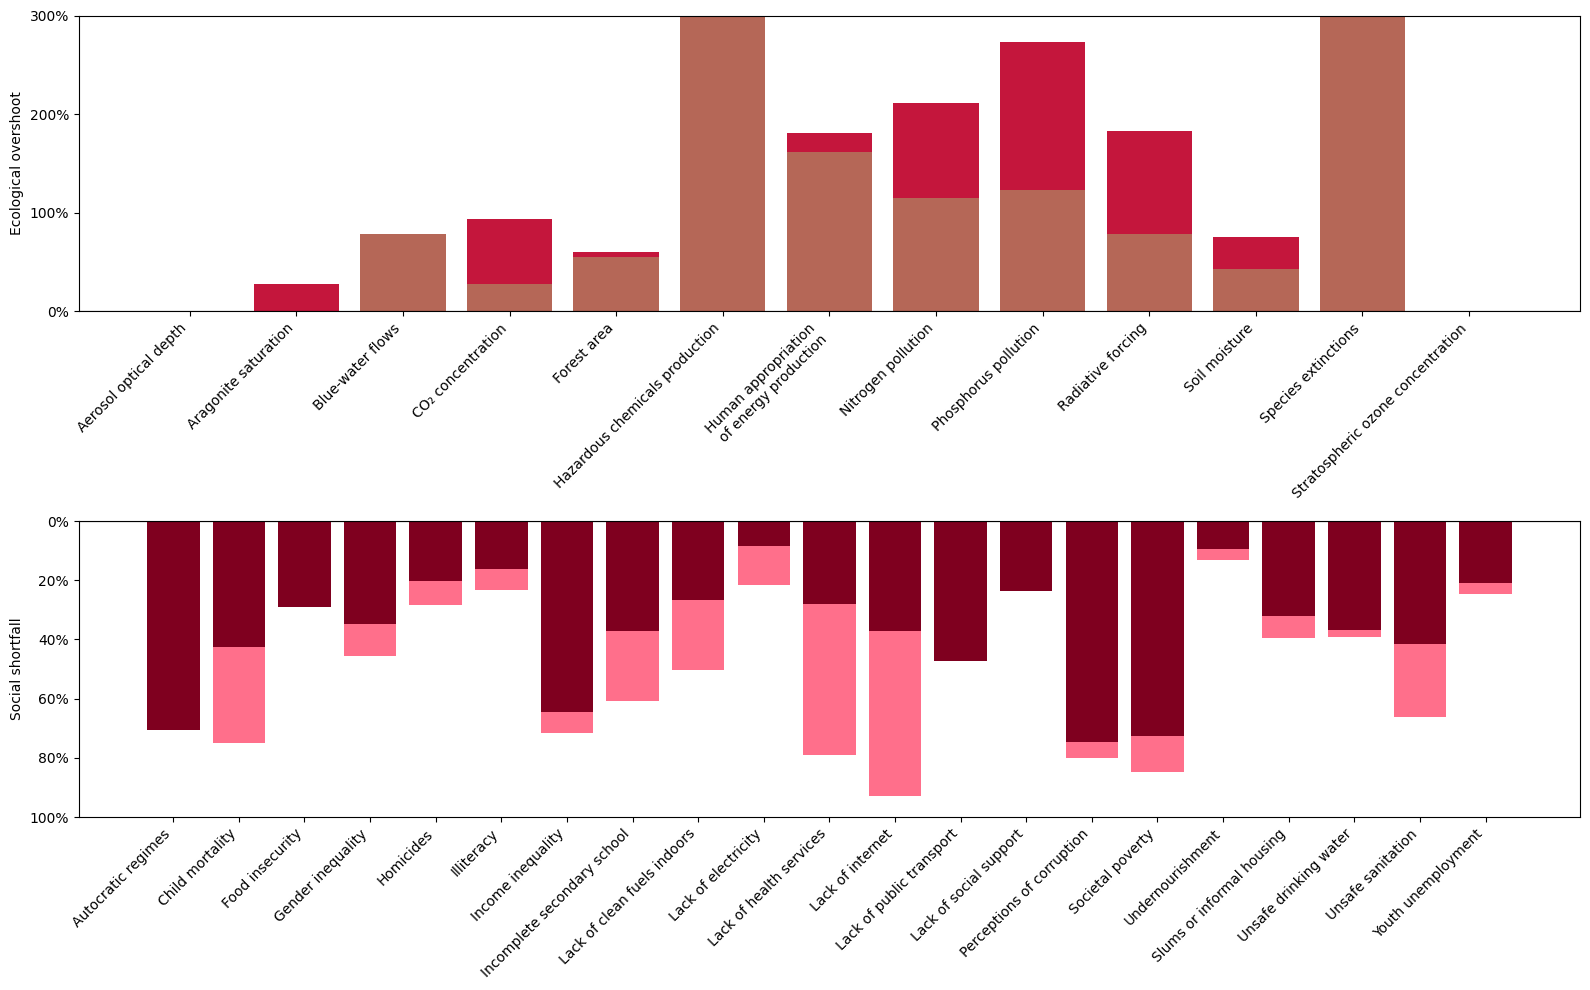

In [40]:
ECO_LIGHT, ECO_DARK = "#b56757", "#c4163c"
SOC_LIGHT, SOC_DARK = "#ff6f8b", "#7f001f"

ec_base = np.clip(
    np.minimum(ec_summary["start_over"], ec_summary["end_over"]),
    0,
    300,
)
ec_inc = np.clip(
    ec_summary["end_over"] - ec_summary["start_over"],
    0,
    300,
)

sf_dark = np.clip(sf_summary["end_short"], 0, 100)
sf_light = np.clip(sf_summary["start_short"] - sf_summary["end_short"], 0, 100)

x_ec = np.arange(len(ec_summary))
x_sf = np.arange(len(sf_summary))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 10),
    gridspec_kw={"height_ratios": [1, 1]}
)

ax_top.bar(x_ec, ec_base, color=ECO_LIGHT, width=0.8)
ax_top.bar(x_ec, ec_inc, bottom=ec_base, color=ECO_DARK, width=0.8)

ax_top.axhline(0, color="black", linewidth=0.8)
ax_top.set_ylim(0, 300)
ax_top.set_yticks([0, 100, 200, 300])
ax_top.set_yticklabels(["0%", "100%", "200%", "300%"])
ax_top.set_ylabel("Ecological overshoot")

ax_top.set_xticks(x_ec)
ax_top.set_xticklabels(ec_summary["label"], rotation=45, ha="right")

ax_bot.bar(x_sf, -sf_dark, color=SOC_DARK, width=0.8)
ax_bot.bar(x_sf, -sf_light, bottom=-sf_dark, color=SOC_LIGHT, width=0.8)

ax_bot.axhline(0, color="black", linewidth=0.8)
ax_bot.set_ylim(-100, 0)
ax_bot.set_yticks([-y for y in [0, 20, 40, 60, 80, 100]])
ax_bot.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax_bot.set_ylabel("Social shortfall")

ax_bot.set_xticks(x_sf)
ax_bot.set_xticklabels(sf_summary["label"], rotation=45, ha="right")

plt.tight_layout()
plt.show()


- Preparing Start and End Arrays for Plotting

    This section extracts and cleans the start and end values for both social shortfalls and ecological overshoot, and prepares corresponding labels for use in plots or summaries.

- Social indicators

    For social indicators, the starting and ending shortfall values are taken from the `sf_summary` table:

      - `start_short` and `end_short` are converted to NumPy arrays for easier numerical manipulation.
      - Any missing values are replaced with 0.0 to avoid issues during plotting or further calculations.
      - All values are clipped to be at least 0, ensuring there are no negative shortfalls.

    The labels for social indicators are then prepared:

      - If a readable `label` column exists in `sf_summary`, those labels are used.
      - Otherwise, the index values (indicator codes) are converted to strings and used as fallback labels.

    These labels will typically appear on the x-axis or in legends.

- Ecological indicators

    For ecological indicators, a similar procedure is followed using the `ec_summary` table:

      - `start_over` and `end_over` (ecological overshoot at the start and end of the period) are converted into NumPy arrays.
      - Missing values are replaced with 0.0.
      - Values are clipped to be at least 0, so overshoot is never negative.

    The labels for ecological indicators are defined in the same way:

      - If a `label` column exists, it is used for human-readable names.
      - Otherwise, the indicator codes from the index are converted to strings.

    By the end of this step, there are clean, non-negative numeric arrays and corresponding label lists for both social and ecological indicators, ready for visualization or further analysis.


In [41]:
sf_start = sf_summary["start_short"].to_numpy()
sf_end   = sf_summary["end_short"].to_numpy()


sf_start = np.nan_to_num(sf_start, nan=0.0)
sf_end   = np.nan_to_num(sf_end,   nan=0.0)
sf_start = np.clip(sf_start, 0, None)
sf_end   = np.clip(sf_end,   0, None)

sf_labels = (
    sf_summary["label"].tolist()
    if "label" in sf_summary.columns
    else sf_summary.index.astype(str).tolist()
)


eco_start = ec_summary["start_over"].to_numpy()
eco_end   = ec_summary["end_over"].to_numpy()


eco_start = np.nan_to_num(eco_start, nan=0.0)
eco_end   = np.nan_to_num(eco_end,   nan=0.0)
eco_start = np.clip(eco_start, 0, None)
eco_end   = np.clip(eco_end,   0, None)

eco_labels = (
    ec_summary["label"].tolist()
    if "label" in ec_summary.columns
    else ec_summary.index.astype(str).tolist()
)

- Integrated “Doughnut” Diagram of Social Foundation and Ecological Ceiling

    This section constructs a radial “doughnut-style” diagram that combines **ecological overshoot** and **social shortfall** into a single visual, inspired by doughnut economics.

    Two reference maxima are defined:
  - `MAX_OVER = 300%` for ecological overshoot,
  - `MAX_SHORT = 100%` for social shortfall.

    These are used to scale the radial length of wedges so that indicators are comparable within their respective domains.

- Ring structure

    The plot consists of:

  - **Inner green ring (Social foundation)**  
    Representing the safe minimum social conditions. Social shortfalls are drawn *inside* this ring, extending inward from its edge.

  - **Outer dark green ring (Ecological ceiling)**  
    Representing the planetary boundaries. Ecological overshoot wedges extend *outside* this ring, showing how far indicators move beyond ecological limits.

    Both rings are full 360° annuli centered at the origin and serve as visual reference bands.

- Ecological overshoot wedges (outside the ecological ceiling)

    For each ecological indicator:

  - The circle is divided into equal angular sectors, one per indicator.
  - Two components are derived from the start and end overshoot values:
    - a **base** overshoot (minimum of start and end, clipped between 0 and `MAX_OVER`),
    - an **increment** (additional overshoot from start to end, clipped so only increases are shown).
  - These are drawn as stacked wedges radiating outward from the outer green ring:
    - the **lighter ecological color** shows the baseline overshoot,
    - the **darker ecological color** shows additional overshoot accumulated over time.

    This highlights both the level and growth of ecological pressure for each indicator.

- Social shortfall wedges (inside the social foundation)

    For each social indicator:

    - The circle is again divided into equal angular sectors, one per indicator.
    - The start and end shortfalls are transformed into:
      - a **dark segment** representing the end shortfall,
      - a **light segment** representing the reduction in shortfall from start to end (improvement), both clipped between 0 and `MAX_SHORT`.
  - These wedges are drawn *inward* from the inner ring:
    - the **darker social color** shows how much shortfall remains,
    - the **lighter social color** shows how much has improved relative to the starting period.

    This visually encodes both current deprivation and progress over time.

  - Labels and layout

  - Text labels at the center and near the outer ring clearly mark the **“SOCIAL FOUNDATION”** and **“ECOLOGICAL CEILING”**.
  - The axes are hidden, and the aspect ratio is set to equal so the figure appears as a clean, circular doughnut.
  - The x–y limits are expanded slightly to ensure all wedges and text are contained within the figure.

    Overall, this diagram offers an integrated view of how humanity is doing relative to:
      - **minimum social standards** (inside the doughnut), and  
      - **maximum ecological limits** (outside the doughnut),  
    while also conveying changes between the start and end of the study period.


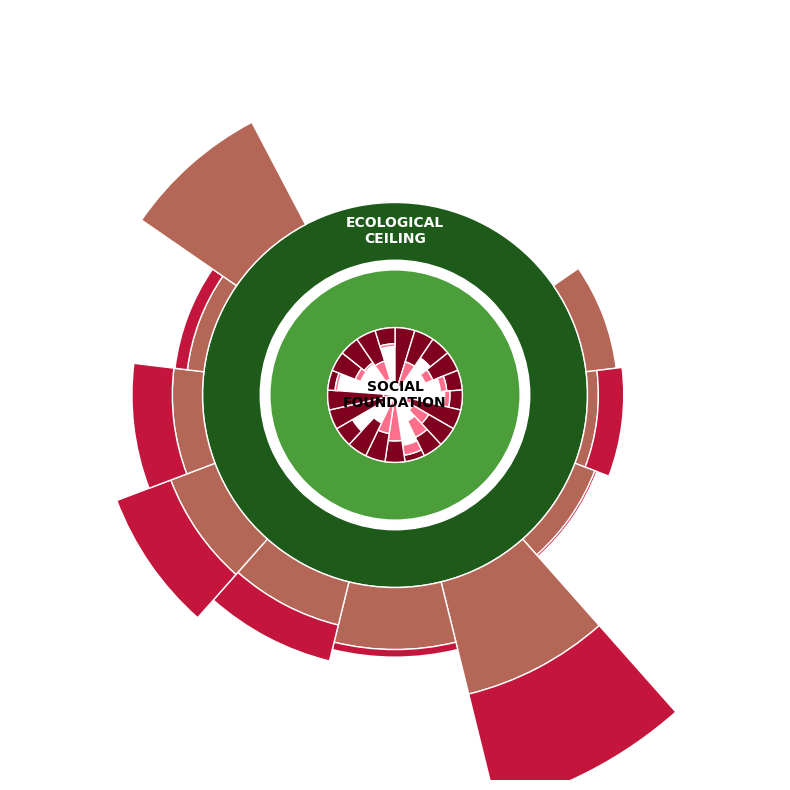

In [42]:
MAX_OVER = 300.0     
MAX_SHORT = 100.0     

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")

inner_ring_inner, inner_ring_outer = 0.35, 0.65   
outer_ring_inner, outer_ring_outer = 0.70, 1.00   

inner_ring = Wedge(
    (0, 0), inner_ring_outer, 0, 360,
    width=inner_ring_outer - inner_ring_inner,
    facecolor="#4b9e3a", edgecolor="white"
)
outer_ring = Wedge(
    (0, 0), outer_ring_outer, 0, 360,
    width=outer_ring_outer - outer_ring_inner,
    facecolor="#1e5b1b", edgecolor="white"
)
ax.add_patch(inner_ring)
ax.add_patch(outer_ring)

theta_step_ec = 360.0 / len(eco_end)
radial_scale_ec = 0.6  

for i, (start_v, end_v, lab) in enumerate(zip(eco_start, eco_end, eco_labels)):
   
    base = max(min(min(start_v, end_v), MAX_OVER), 0.0)
    inc  = max(min(end_v - start_v, MAX_OVER), 0.0)

    theta1 = 90 - (i + 1) * theta_step_ec
    theta2 = 90 - i * theta_step_ec

    r0 = outer_ring_outer
    r1 = r0 + base / MAX_OVER * radial_scale_ec
    if base > 0:
        ax.add_patch(
            Wedge((0, 0), r1, theta1, theta2,
                  width=r1 - r0, facecolor=ECO_LIGHT, edgecolor="white")
        )

    if inc > 0:
        r2 = r1 + inc / MAX_OVER * radial_scale_ec
        ax.add_patch(
            Wedge((0, 0), r2, theta1, theta2,
                  width=r2 - r1, facecolor=ECO_DARK, edgecolor="white")
        )


theta_step_sf = 360.0 / len(sf_end)
radial_scale_sf = 0.40  

for i, (start_v, end_v, lab) in enumerate(zip(sf_start, sf_end, sf_labels)):
    
    start = max(min(start_v, MAX_SHORT), 0.0)
    end   = max(min(end_v,   MAX_SHORT), 0.0)
    dark  = max(min(end, MAX_SHORT), 0.0)
    light = max(min(start - end, MAX_SHORT), 0.0)

    theta1 = 90 - (i + 1) * theta_step_sf
    theta2 = 90 - i * theta_step_sf

    r1 = inner_ring_inner
    r0 = r1 - dark / MAX_SHORT * radial_scale_sf
    if dark > 0:
        ax.add_patch(
            Wedge((0, 0), r1, theta1, theta2,
                  width=r1 - r0, facecolor=SOC_DARK, edgecolor="white")
        )

    if light > 0:
        r0b = r0 - light / MAX_SHORT * radial_scale_sf
        ax.add_patch(
            Wedge((0, 0), r0, theta1, theta2,
                  width=r0 - r0b, facecolor=SOC_LIGHT, edgecolor="white")
        )

ax.text(0, 0, "SOCIAL\nFOUNDATION",
        ha="center", va="center",
        fontsize=10, fontweight="bold")

ax.text(0, (outer_ring_inner + outer_ring_outer) / 2,
        "ECOLOGICAL\nCEILING",
        ha="center", va="center",
        color="white", fontsize=10, fontweight="bold")

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.axis("off")

plt.tight_layout()
plt.show()
